<a href="https://colab.research.google.com/github/ramandeepp1403/retail-demand-forecasting/blob/main/Retail_Forecasting_End_to_End.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Store Item Demand Forecasting
End-to-end project with EDA, Feature Engineering, Machine Learning, CNN, Evaluation and Model Saving.

In [ ]:
!pip -q install statsmodels xgboost
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv1D,MaxPooling1D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


In [ ]:
df=pd.read_csv('train.csv',parse_dates=['date'])
df
display(df.head())
df.info()
display(df.describe())
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


date     0
store    0
item     0
sales    0
dtype: int64
Duplicates: 0


In [ ]:
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


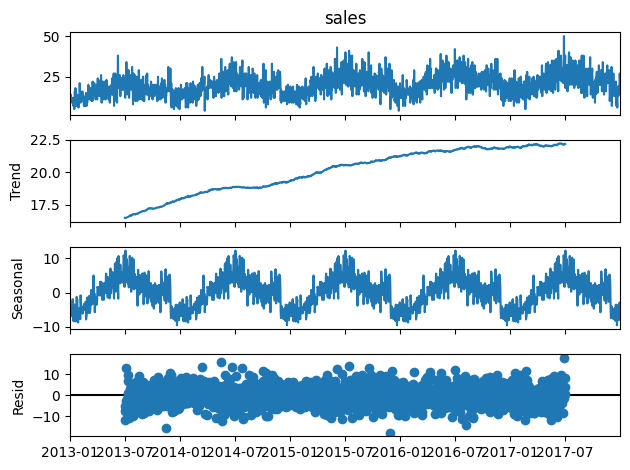

ADF: -3.157670556332821
p-value: 0.022569380626570427


In [ ]:
sample=df[(df.store==1)&(df.item==1)].set_index("date")
seasonal_decompose(sample.sales,model="additive",period=365).plot()
plt.show()

def adf(series):
    result=adfuller(series)
    print("ADF:",result[0])
    print("p-value:",result[1])

adf(sample.sales)


In [ ]:
df['day_of_week']=df.date.dt.dayofweek
df['month']=df.date.dt.month
df['year']=df.date.dt.year
df['day_of_year']=df.date.dt.dayofyear
df['week']=df.date.dt.isocalendar().week.astype(int)
df['quarter']=df.date.dt.quarter
df['is_weekend']=(df.day_of_week>=5).astype(int)

for lag in [1,2,3,7,14,21,30]:
    df[f'lag_{lag}']=df.groupby(['store','item'])['sales'].transform(lambda x:x.shift(lag))

for w in [7,14,30]:
    df[f'roll_mean_{w}']=df.groupby(['store','item'])['sales'].transform(lambda x:x.shift(1).rolling(w).mean())
    df[f'roll_std_{w}']=df.groupby(['store','item'])['sales'].transform(lambda x:x.shift(1).rolling(w).std())

df.dropna(inplace=True)


In [ ]:
X=df.drop(['sales','date'],axis=1)
y=df.sales

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,shuffle=False)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("-" * 30)
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R²  :", r2_score(y_test, lr_pred))

Linear Regression Results
------------------------------
MAE : 5.984790465496828
RMSE: 7.743411822802099
R²  : 0.9069091952485316


In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Results")
print("-" * 30)
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R²  :", r2_score(y_test, dt_pred))

Decision Tree Results
------------------------------
MAE : 8.022522271714923
RMSE: 10.492185818582817
R²  : 0.8290874251200014


In [ ]:
X_train_cnn=X_train_scaled.reshape(X_train_scaled.shape[0],X_train_scaled.shape[1],1)
X_test_cnn=X_test_scaled.reshape(X_test_scaled.shape[0],X_test_scaled.shape[1],1)

cnn=Sequential([
Conv1D(64,2,activation='relu',input_shape=(X_train_cnn.shape[1],1)),
BatchNormalization(),
Conv1D(128,2,activation='relu'),
BatchNormalization(),
MaxPooling1D(),
Dropout(0.2),
Flatten(),
Dense(128,activation='relu'),
Dropout(0.3),
Dense(64,activation='relu'),
Dense(1)
])

cnn.compile(optimizer='adam',loss='mse',metrics=['mae'])

early=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history=cnn.fit(
X_train_cnn,
y_train,
validation_data=(X_test_cnn,y_test),
epochs=15,
batch_size=256,
callbacks=[early],
verbose= 1
)


Epoch 1/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 198s 67ms/step - loss: 100.9437 - mae: 7.4192 - val_loss: 170.1738 - val_mae: 9.7984
Epoch 2/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 186s 66ms/step - loss: 75.6004 - mae: 6.6465 - val_loss: 272.2970 - val_mae: 13.3450
Epoch 3/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 178s 64ms/step - loss: 71.9214 - mae: 6.4962 - val_loss: 236.6665 - val_mae: 12.0222
Epoch 4/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 179s 64ms/step - loss: 70.1033 - mae: 6.4161 - val_loss: 250.7827 - val_mae: 12.8414
Epoch 5/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 203s 64ms/step - loss: 68.6968 - mae: 6.3579 - val_loss: 235.7436 - val_mae: 11.9717
Epoch 6/15
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 204s 65ms/step - loss: 67.7598 - mae: 6.3173 - val_loss: 245.0079 - val_mae: 12.4875


5613/5613 ━━━━━━━━━━━━━━━━━━━━ 54s 10ms/step
MAE: 9.798380851745605
RMSE: 13.04506969639446
R2: 0.7357987761497498


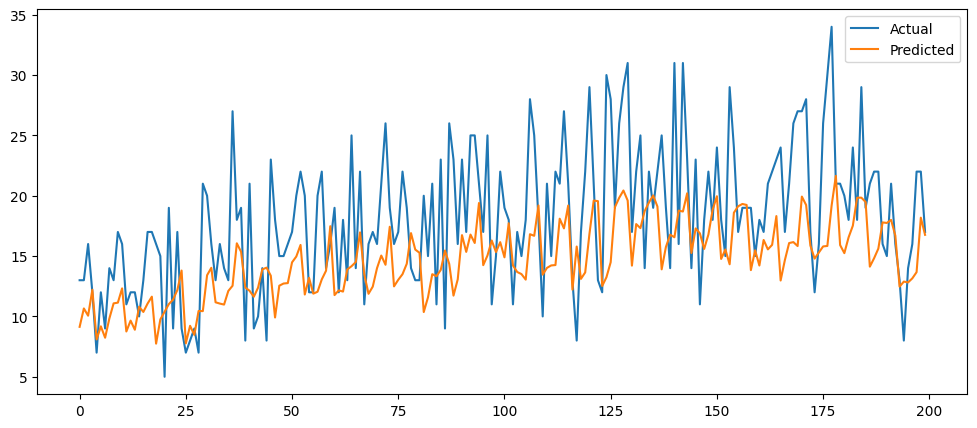

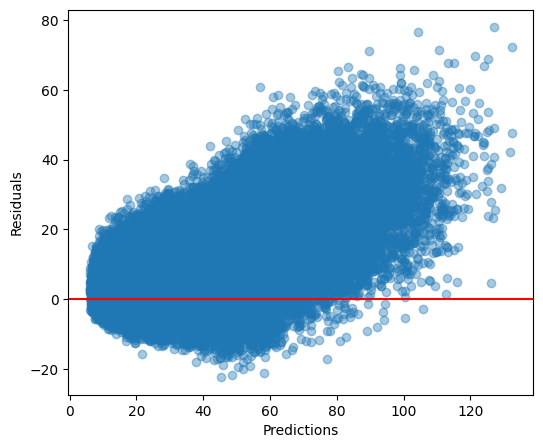

In [ ]:
pred=cnn.predict(X_test_cnn).flatten()

mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200],label='Actual')
plt.plot(pred[:200],label='Predicted')
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(pred,y_test-pred,alpha=0.4)
plt.axhline(0,color='red')
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()


Linear Regression Performance
-----------------------------------
MAE  : 5.9848
RMSE : 7.7434
R²   : 0.9069


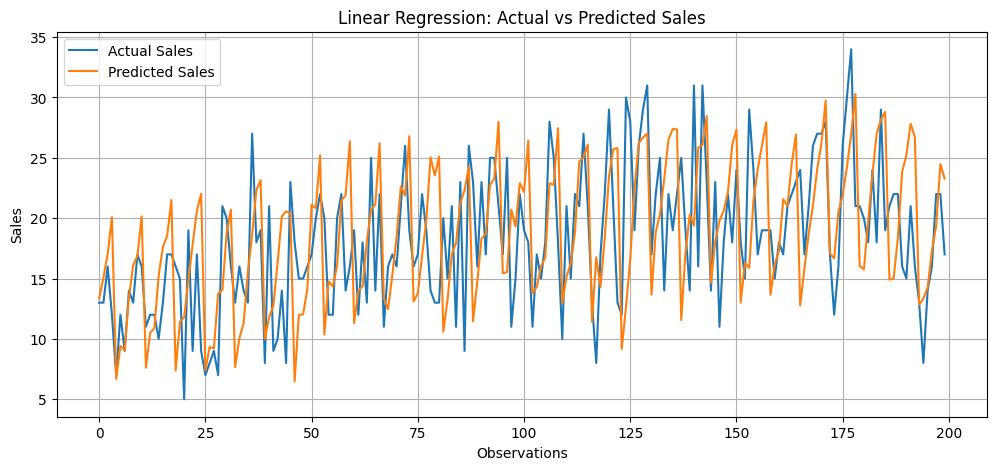

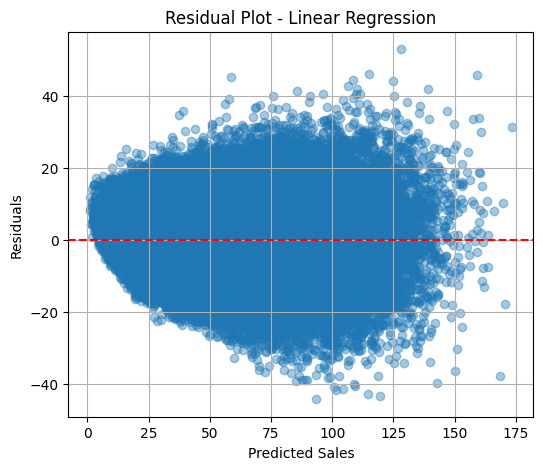

In [ ]:
lr_pred = lr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label='Actual Sales')
plt.plot(lr_pred[:200], label='Predicted Sales')

plt.title("Linear Regression: Actual vs Predicted Sales")
plt.xlabel("Observations")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

#residual plot
residuals = y_test - lr_pred

plt.figure(figsize=(6,5))

plt.scatter(lr_pred, residuals, alpha=0.4)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.grid(True)

plt.show()

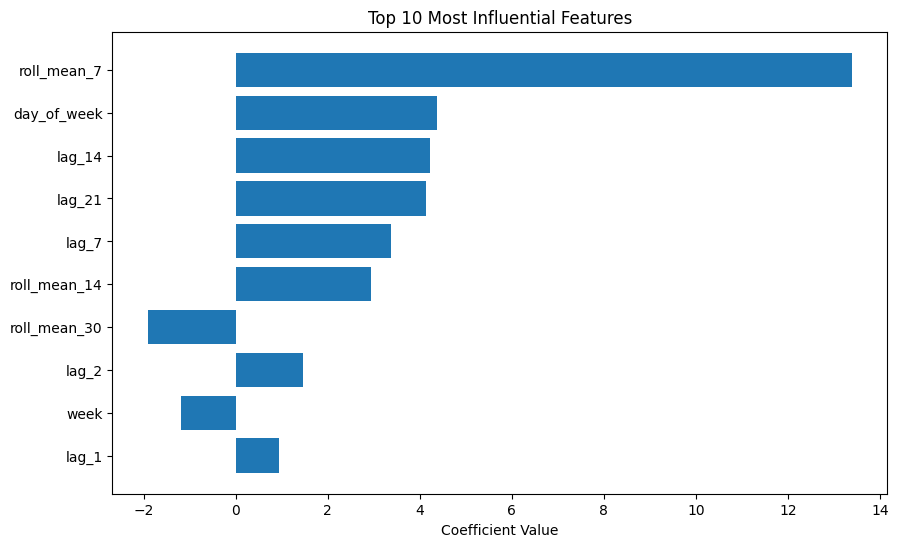

,Feature,Coefficient,Absolute Coefficient
16,roll_mean_7,13.398654,13.398654
2,day_of_week,4.375590,4.375590
13,lag_14,4.231282,4.231282
14,lag_21,4.139448,4.139448
12,lag_7,3.379718,3.379718
18,roll_mean_14,2.934893,2.934893
20,roll_mean_30,-1.911955,1.911955
10,lag_2,1.472088,1.472088
6,week,-1.184099,1.184099
9,lag_1,0.935408,0.935408


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    coefficients["Feature"][:10],
    coefficients["Coefficient"][:10]
)

plt.title("Top 10 Most Influential Features")
plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()

plt.show()

display(coefficients.head(10))

In [ ]:
results = {
    "Model": ["Linear Regression", "Decision Tree","CNN"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, pred)   # pred = CNN predictions
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),

        r2_score(y_test, pred)
    ]
}

results_df = pd.DataFrame(results)

display(results_df.sort_values(by="RMSE"))

,Model,MAE,RMSE,R2
0,Linear Regression,5.984790,7.743412,0.906909
1,Decision Tree,8.022522,10.492186,0.829087
2,CNN,9.798381,13.045070,0.735799


In [ ]:
import joblib

joblib.dump(lr, "linear_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [ ]:
import joblib

# Load model
model = joblib.load("linear_regression_model.pkl")

# Load scaler
scaler = joblib.load("scaler.pkl")

# Sample input
sample = X.iloc[[0]]

# Scale
sample_scaled = scaler.transform(sample)

# Predict
prediction = model.predict(sample_scaled)

print("Predicted Sales:", prediction[0])

Predicted Sales: 12.753477907069865


In [ ]:
print("Actual Sales:", y.iloc[0])
print("Predicted Sales:", prediction[0])

Actual Sales: 10
Predicted Sales: 12.753477907069865


In [31]:
print(X.columns.tolist())

['store', 'item', 'day_of_week', 'month', 'year', 'day_of_year', 'week', 'quarter', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_30', 'roll_std_30']


In [32]:
import pandas as pd

new_data = pd.DataFrame({
    "store": [2],
    "item": [10],
    "day_of_week": [4],      # Friday (0=Monday)
    "month": [8],
    "year": [2017],
    "day_of_year": [220],
    "week": [32],
    "quarter": [3],
    "is_weekend": [0],

    "lag_1": [18],
    "lag_2": [17],
    "lag_3": [19],
    "lag_7": [20],
    "lag_14": [18],
    "lag_21": [17],
    "lag_30": [16],

    "roll_mean_7": [18.6],
    "roll_std_7": [1.20],

    "roll_mean_14": [18.1],
    "roll_std_14": [1.45],

    "roll_mean_30": [17.8],
    "roll_std_30": [1.72]
})

# Scale
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

print(f"Predicted Sales: {prediction[0]:.2f} units")

Predicted Sales: 21.33 units
